# Лабораторная работа №2. Кластеризация клиентов интернет-магазина

#### Цель

- освоить методы k-means и агломеративной кластеризации на большом реальном датасете
транзакций
- научиться применять RFM-анализ для сегментации клиентов
- определять оптимальное число кластеров с помощью метода локтя и силуэтного анализа
- интерпретировать кластеры как бизнес-сегменты

#### Датасет

Online Retail по покупкам в интернет-магазине, локализованном в регионе с
индексом 1, пользователями из 39 регионов - 541 909 транзакций, 4 372 клиента, по ссылке
https://docs.google.com/spreadsheets/d/1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx/edit?usp=sharing&ouid=114596079979601215791&rtpof=true&sd=true

#### Задача

Сегментировать клиентов по их покупательскому поведению, чтобы отдел маркетинга мог запускать таргетированные кампании: удерживать «ценных», реактивировать «спящих», стимулировать «новичков».

#### Признаки

| Признак | Описание |
|---|---|
| **InvoiceNo** | Номер счёта (6 цифр, уникальный для каждой транзакции) |
| **StockCode** | Код товара (5 цифр) |
| **Description** | Название товара |
| **Quantity** | Количество единиц товара в транзакции |
| **InvoiceDate** | Дата и время выставления счёта |
| **UnitPrice** | Цена за единицу товара |
| **CustomerID** | Идентификатор клиента (5 цифр) |
| **Region** | Код региона проживания клиента |

## Задание 1. Загрузка и EDA

In [2]:
import pandas as pd

In [3]:
df = pd.read_excel('https://docs.google.com/spreadsheets/d/1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx/export?format=xlsx&id=1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Region
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2024-12-01 08:26:00,285.60,17850.0,1
1,536365,71053,WHITE METAL LANTERN,6,2024-12-01 08:26:00,379.68,17850.0,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2024-12-01 08:26:00,308.00,17850.0,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2024-12-01 08:26:00,379.68,17850.0,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2024-12-01 08:26:00,379.68,17850.0,1


In [4]:
print(f'Строк: {len(df)}')
print(f'Пропуски:\n{df.isna().sum()}')
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df_returns = df[df['Quantity'] <= 0].copy()
df = df[(df['Quantity'] > 0) | (df['UnitPrice'] > 0)].copy()
print('\n')
print('ПОСЛЕ ОЧИСТКИ')
print(f'Покупок: {len(df)}')
print(f'Возвратов: {len(df_returns)}')
print(f'Уникальных клиентов: {df['CustomerID'].nunique()}')

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

Строк: 541909
Пропуски:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Region              0
dtype: int64


ПОСЛЕ ОЧИСТКИ
Покупок: 406829
Возвратов: 8905
Уникальных клиентов: 4372


In [5]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,406829.000000,4.068290e+05,4.068290e+05
mean,12.061303,3.875728e+02,2.285008e+03
std,248.693370,7.763298e+03,4.789027e+04
min,-80995.000000,0.000000e+00,-1.886860e+07
25%,2.000000,1.400000e+02,4.704000e+02
50%,5.000000,2.184000e+02,1.243200e+03
75%,12.000000,4.200000e+02,2.184000e+03
max,80995.000000,4.364640e+06,1.886860e+07


Видно большой std относительно mean - большой разброс.
max сильно больше 75% - выбросы.

In [6]:
df['Region'].value_counts().head(10)

Region
1     361878
9       9495
2       8491
5       7485
7       2533
4       2371
13      2069
22      1877
28      1480
3       1259
Name: count, dtype: int64

По числу транзакций доминирует регион 1.

In [7]:
import matplotlib.pyplot as plt

%matplotlib inline

In [8]:
monthly = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
print(monthly)

InvoiceDate
2024-12-31    6.211565e+07
2025-01-31    5.320833e+07
2025-02-28    4.889317e+07
2025-03-31    6.495604e+07
2025-04-30    4.771736e+07
2025-05-31    7.260412e+07
2025-06-30    6.809747e+07
2025-07-31    6.431471e+07
2025-08-31    6.903322e+07
2025-09-30    1.043213e+08
2025-10-31    1.091556e+08
2025-11-30    1.268297e+08
2025-12-31    3.836071e+07
Freq: ME, Name: TotalPrice, dtype: float64


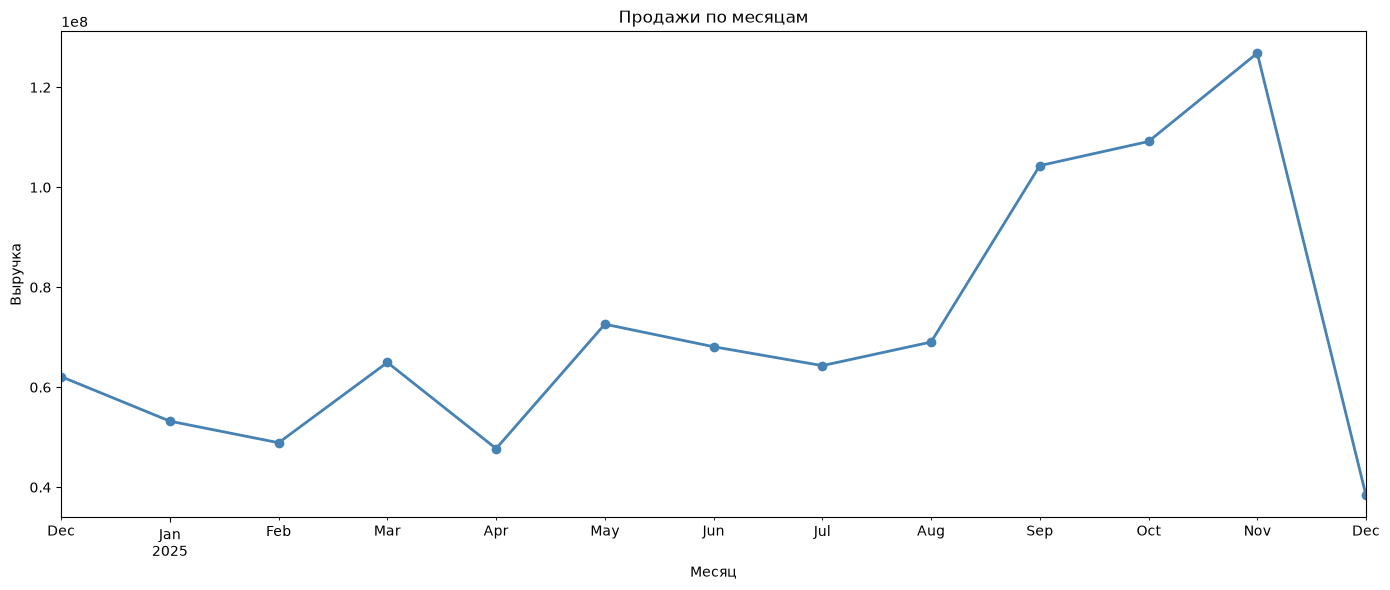

In [9]:
plt.figure(figsize=(14, 6))
monthly.plot(marker='o', color='steelblue', linewidth=2)
plt.title('Продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.tight_layout()
plt.show()

Пик ближе к концу 2025 года, данные за декабрь не полные.

## Задание 2. RFM-анализ (Recency, Frequency, Monetary)

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [40]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,2,0.00
12347,2,7,482720.00
12348,75,4,201290.88
12349,19,1,196845.60
12350,310,1,37452.80


In [23]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [25]:
import seaborn as sns

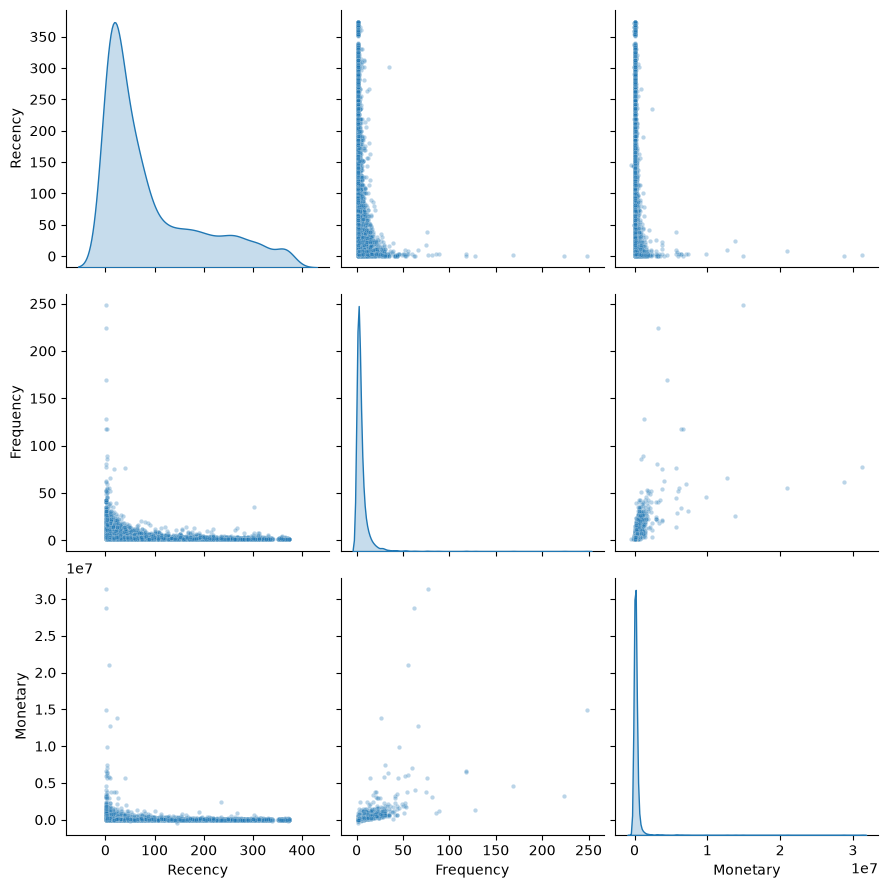

In [37]:
sns.pairplot(rfm, diag_kind='kde', height=3, plot_kws={'alpha': 0.3, 's': 10})

In [38]:
import numpy as np

d:\projects\asu\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


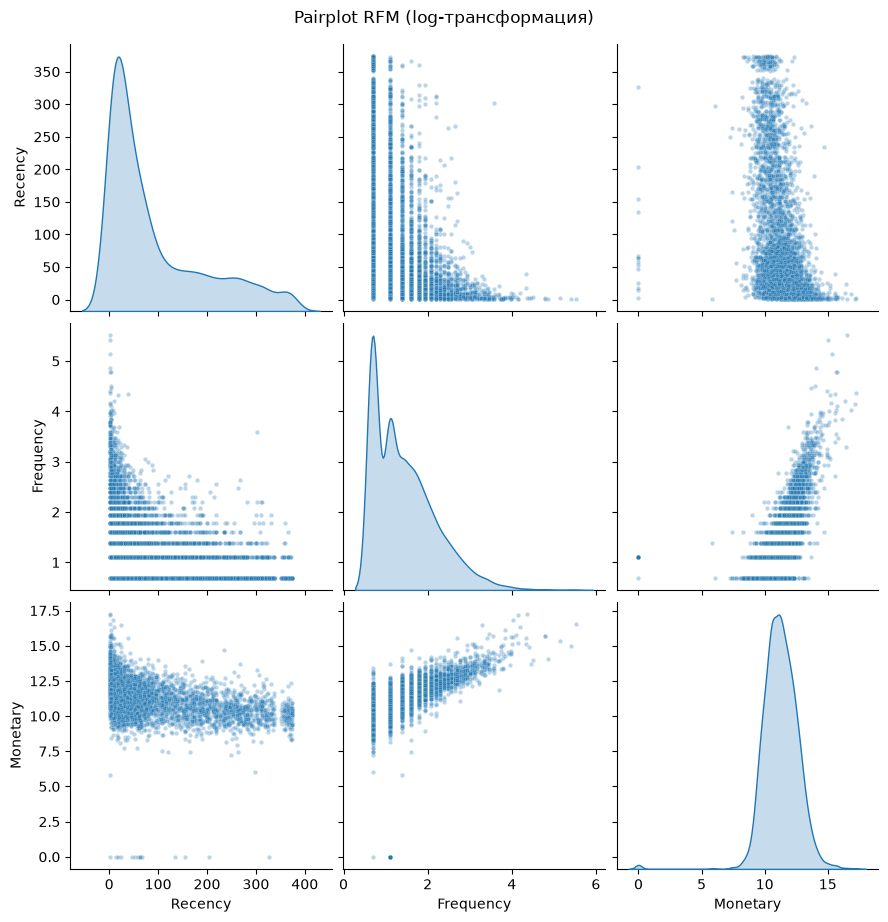

In [42]:
# Логарифмируем Frequency и Monetary
rfm_log = rfm.copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

# Pairplot на логарифмированных данных
sns.pairplot(rfm_log, diag_kind='kde', height=3, plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot RFM (log-трансформация)', y=1.02)
plt.show()

- На гистограмме R видно много клиентов покупающих недавно.
- На гистограмме F видно два пика, первый пик - клиенты покупающие один раз, второй - больше.
- На гистограмме M видно нормально распределение.
- На F x M видна зависимость - чем чаще покупают тем больше сумма.
- На R x M снизу видны аномалии с около нулевой суммой.

"На глаз" видно две группы, покупающие недавно часто и покупающие давно и редко.